# A Demo for Urbach plot and tauc plot

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

1. Import a UV-VIS data

In [2]:
ABS_file = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/UV-VIS/MA_Data/Data_To_Use/R5_30So.csv'
Absorb_df = pd.read_csv(ABS_file)#, usecols = ["wavelength", "absorbance"])
wavelength = np.array(Absorb_df["nm"].tolist())
absorbance = np.array(Absorb_df["A"].tolist())

eV = 1240/wavelength
tauc_intensity = (eV * absorbance)**2


### Absorbance vs. Wavelength

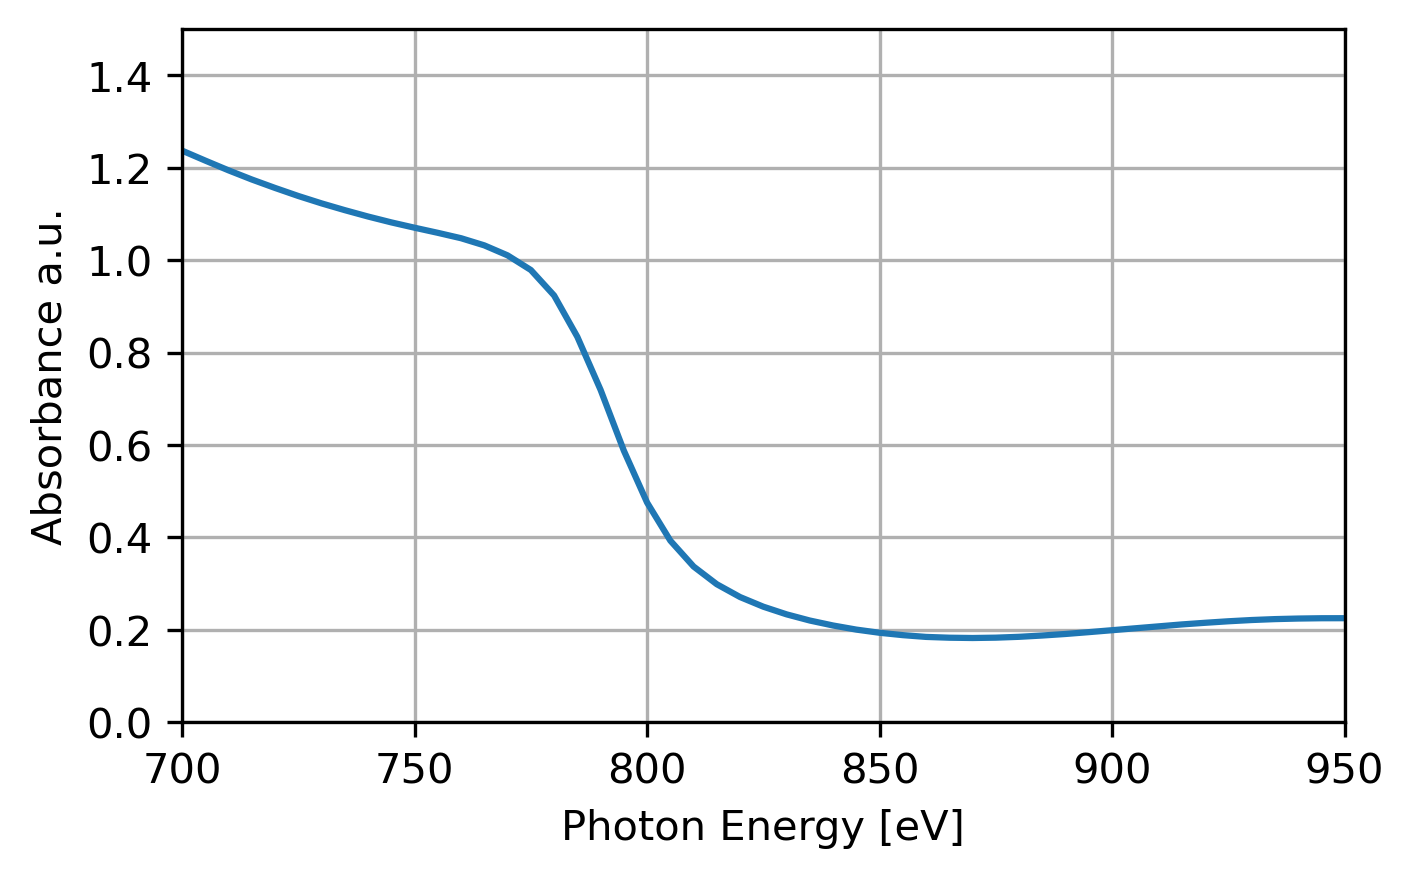

In [20]:
plt.figure(figsize = (5, 3), dpi =300)
plt.plot(wavelength, absorbance)
plt.xlim(700, 950)
plt.ylim(0, 1.5)
plt.ylabel("Absorbance a.u.")
plt.xlabel("Photon Energy [eV]")
plt.grid()

### Do a quick plot for the tauc plot

Text(0, 0.5, '(α E)^1/r')

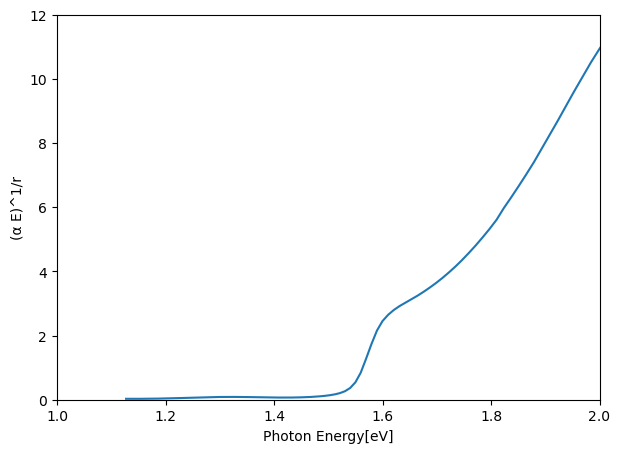

In [4]:
plt.figure(figsize = (7, 5))
plt.plot(eV, tauc_intensity)
plt.ylim(0, 12)
plt.xlim(1, 2)
plt.xlabel("Photon Energy[eV]")
plt.ylabel(f"(α E)^1/r")

(1.4, 1.8)

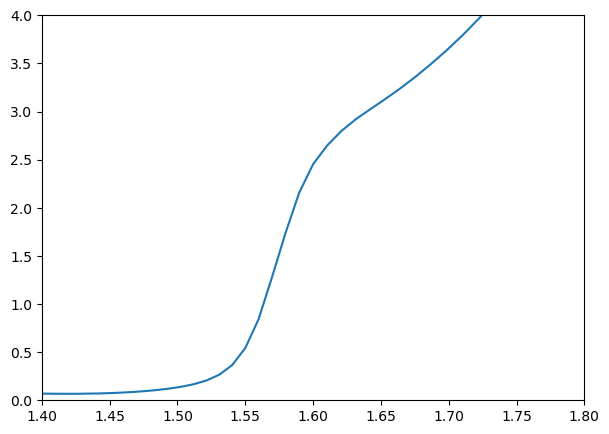

In [5]:
#Closeup, use this to demostrate
plt.figure(figsize = (7, 5))
plt.plot(eV, tauc_intensity)
plt.ylim(0, 4)
plt.xlim(1.4, 1.8)

### Linear regression for the band gap

In [6]:
x = eV.reshape(-1, 1)
y = tauc_intensity.reshape(-1, 1)
mask = (x > 1.56) & (x < 1.59)
x_selected = x[mask].reshape(-1, 1)
y_selected = y[mask].reshape(-1, 1)
print(x_selected)

[[1.56962025]
 [1.57961783]
 [1.58974359]]


In [7]:
tauc_fit = LinearRegression().fit(x_selected, y_selected)
tauc_slope = tauc_fit.coef_[0, 0]
tauc_intercept = tauc_fit.intercept_[0]
tauc_r_squared = tauc_fit.score(x_selected, y_selected)
tauc_x_intercept = -tauc_intercept / tauc_slope
print(f"Slope: {tauc_slope:.4f}")
print(f"Intercept: {tauc_intercept:.4f}")
print(f"R^2: {tauc_r_squared:.4f}")
print(f"Tauc gap (x-intercept): {tauc_x_intercept:.4f} eV")


Slope: 43.7879
Intercept: -67.4478
R^2: 0.9991
Tauc gap (x-intercept): 1.5403 eV


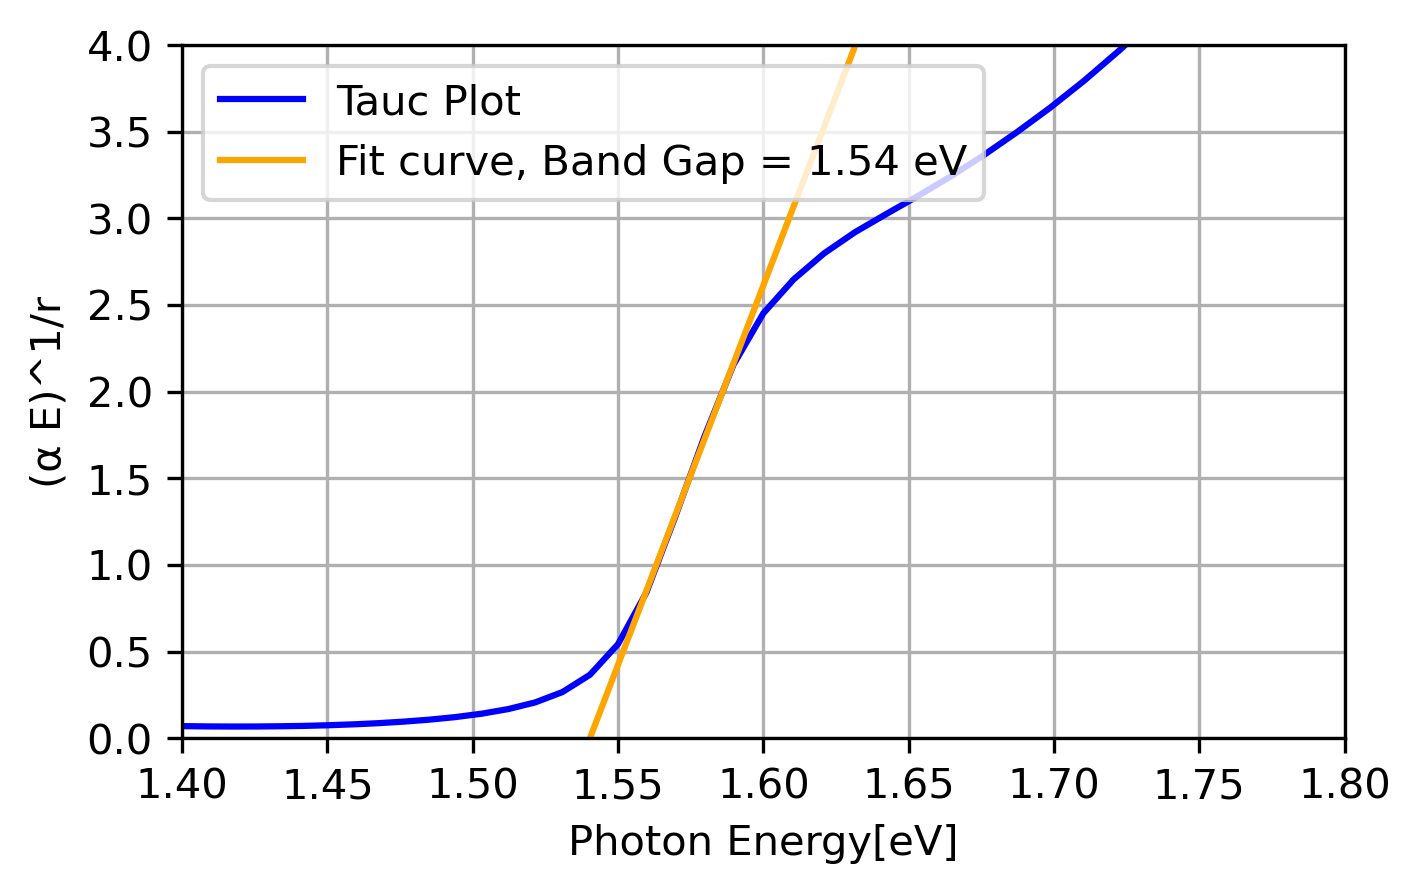

In [8]:
#Closeup, use this to demostrate
plt.figure(figsize = (5, 3), dpi = 300)
plt.plot(eV, tauc_intensity, color = 'blue', label = "Tauc Plot")
plt.plot(eV, eV * tauc_slope + tauc_intercept, color = "orange", label = f"Fit curve, Band Gap = {tauc_x_intercept:.2f} eV")
plt.ylim(0, 4)
plt.xlim(1.4, 1.8)
plt.xlabel("Photon Energy[eV]")
plt.ylabel(f"(α E)^1/r")
plt.legend()
plt.grid()

### Linear Regression for the Urbach Energy

In [9]:
tauc_ln = np.log(tauc_intensity)

(-4.0, 2.0)

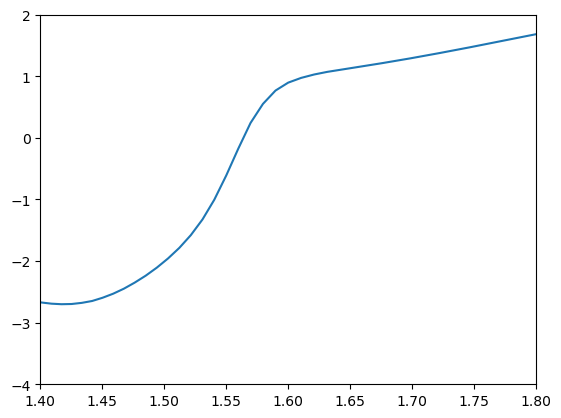

In [10]:
#Quick Plot:
plt.plot(eV, tauc_ln)
plt.xlim(1.4, 1.8)
plt.ylim(-4, 2)

In [11]:
urbach_x = eV.reshape(-1, 1)
urbach_y = tauc_ln.reshape(-1, 1)
mask_urbach = (urbach_x > 1.53) & (urbach_x < 1.56)
urbach_x_selected = urbach_x[mask_urbach].reshape(-1, 1)
urbach_y_selected = urbach_y[mask_urbach].reshape(-1, 1)


In [12]:
print("Tauc")
print(x_selected)
print(y_selected)
print("Urbach")
print(urbach_x_selected)
print(urbach_y_selected)

Tauc
[[1.56962025]
 [1.57961783]
 [1.58974359]]
[[1.27466135]
 [1.73586244]
 [2.15591859]]
Urbach
[[1.5308642 ]
 [1.54037267]
 [1.55      ]
 [1.55974843]]
[[-1.32423782]
 [-1.00423447]
 [-0.61104942]
 [-0.17393976]]


In [13]:
urbach_fit = LinearRegression().fit(urbach_x_selected, urbach_y_selected)

urbach_slope = urbach_fit.coef_[0, 0]
urbach_intercept = urbach_fit.intercept_[0]
urbach_r_squared = urbach_fit.score(x_selected, y_selected)
urbach_x_intercept = -urbach_intercept / urbach_slope
print(f"Slope: {urbach_slope:.4f}")
print(f"Intercept: {urbach_intercept:.4f}")
print(f"R^2: {urbach_r_squared:.4f}")
print(f"Urbach gap (x-intercept): {urbach_x_intercept:.4f} eV")
Urbach_Energy = 1/ urbach_slope


Slope: 39.9399
Intercept: -62.4954
R^2: -8.7971
Urbach gap (x-intercept): 1.5647 eV


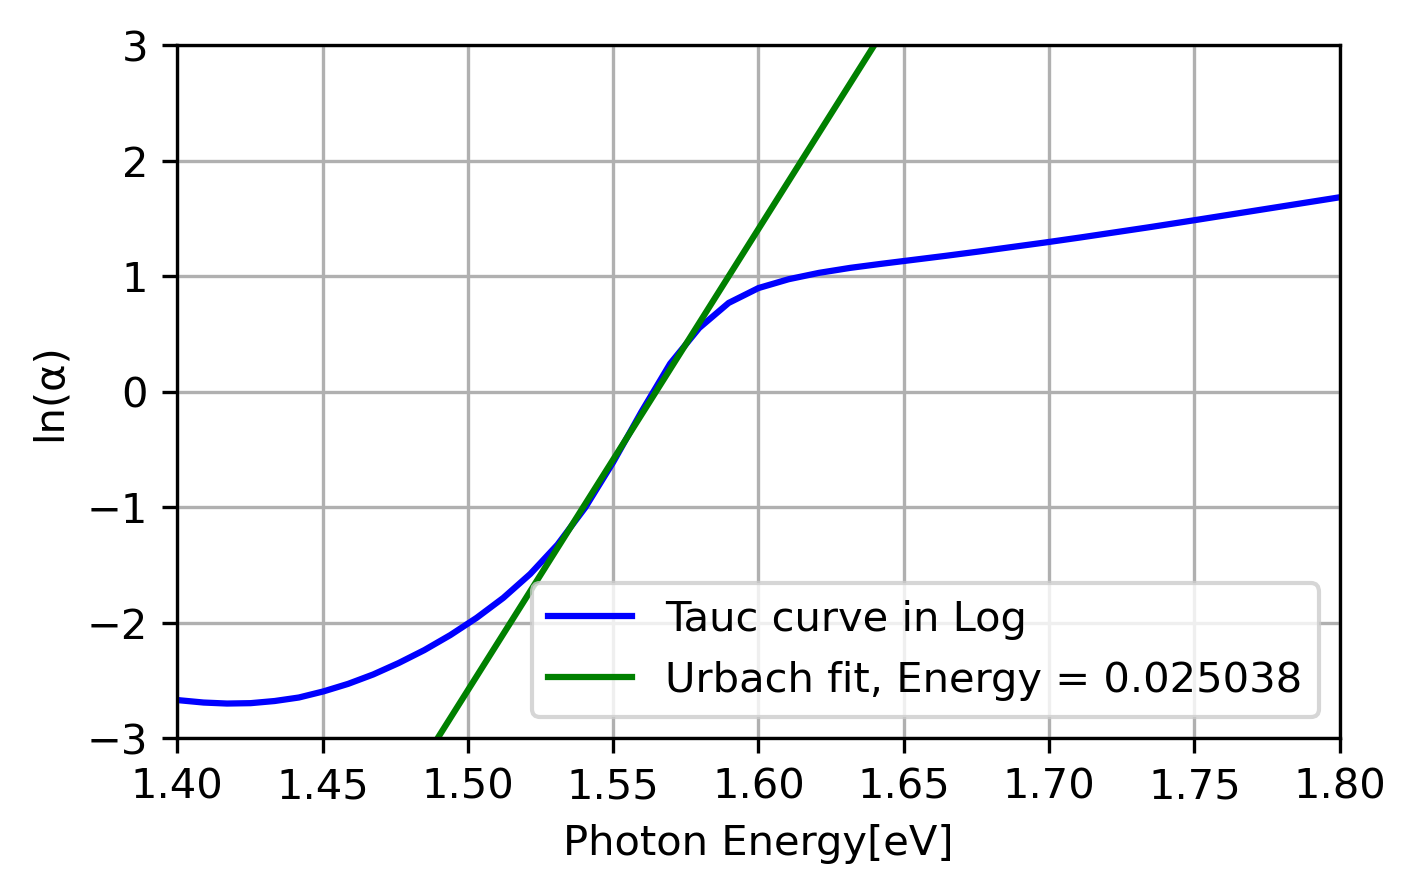

In [14]:
plt.figure(figsize=(5, 3), dpi = 300)
plt.plot(eV, tauc_ln, color = "blue", label = "Tauc curve in Log")
#plt.plot(eV, np.log(eV * tauc_slope + tauc_intercept), color = "orange", label = f"Tauc Fit, band gap = {urbach_x_intercept:2f}")
plt.plot(eV, (eV * urbach_slope + urbach_intercept), color = "green", label = f"Urbach fit, Energy = {Urbach_Energy:2f}")
plt.xlim(1.4, 1.8)
plt.ylim(-3, 3)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("ln(α)")
plt.legend()
plt.grid()

### Do the original plot with urbach fit

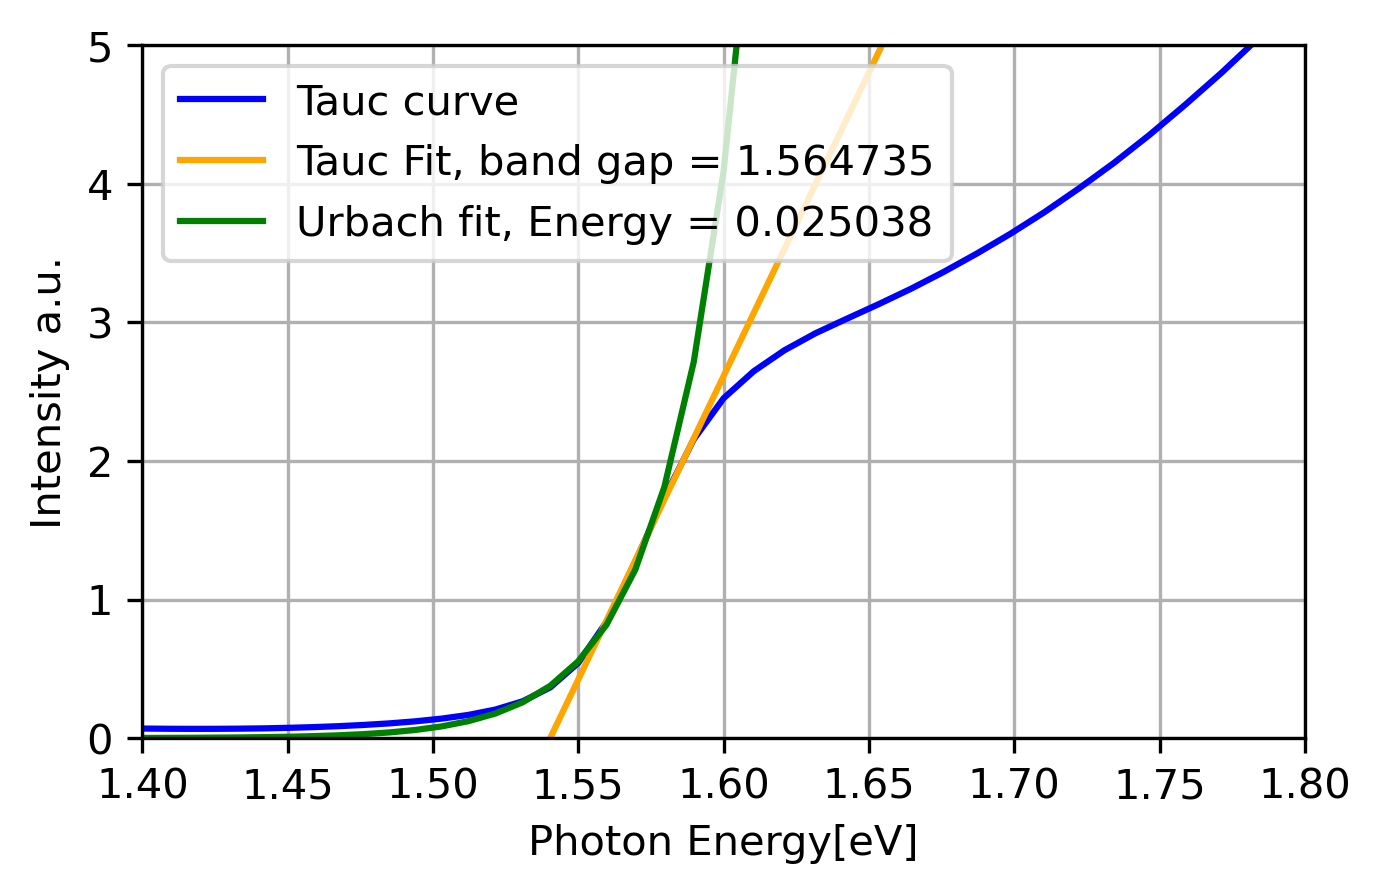

In [15]:
plt.figure(figsize=(5, 3), dpi = 300)
plt.plot(eV, tauc_intensity, color = "blue", label = "Tauc curve")
plt.plot(eV, (eV * tauc_slope + tauc_intercept), color = "orange", label = f"Tauc Fit, band gap = {urbach_x_intercept:2f}")
plt.plot(eV, np.exp(eV * urbach_slope + urbach_intercept), color = "green", label = f"Urbach fit, Energy = {Urbach_Energy:2f}")
plt.xlim(1.4, 1.8)
plt.ylim(0, 5)
plt.xlabel("Photon Energy[eV]")
plt.ylabel("Intensity a.u.")
plt.legend()
plt.grid()